# **Bike-Sharing Rental : Demand Prediction**

# **1. EDA**

**1. Data Loading**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [2]:
# Load the dataset
df = pd.read_csv('Dataset.csv')

print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Dataset contains 17379 rows and 17 columns


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [3]:
# Check structure and placeholders
print(f"Dataset Dimensions: {df.shape}")
print("\nUnique values in categorical columns (Checking for '?'):")
for col in df.select_dtypes(include='object').columns:
    if '?' in df[col].values:
        print(f"- {col}: Contains '?' placeholders")

display(df.head())


Dataset Dimensions: (17379, 17)

Unique values in categorical columns (Checking for '?'):
- season: Contains '?' placeholders
- yr: Contains '?' placeholders
- mnth: Contains '?' placeholders
- holiday: Contains '?' placeholders
- workingday: Contains '?' placeholders
- weathersit: Contains '?' placeholders
- temp: Contains '?' placeholders
- atemp: Contains '?' placeholders
- hum: Contains '?' placeholders
- windspeed: Contains '?' placeholders
- casual: Contains '?' placeholders
- registered: Contains '?' placeholders


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   instant     17379 non-null  int64 
 1   dteday      17379 non-null  object
 2   season      17379 non-null  object
 3   yr          17379 non-null  object
 4   mnth        17379 non-null  object
 5   hr          17379 non-null  int64 
 6   holiday     17379 non-null  object
 7   weekday     17379 non-null  int64 
 8   workingday  17379 non-null  object
 9   weathersit  17379 non-null  object
 10  temp        17379 non-null  object
 11  atemp       17379 non-null  object
 12  hum         17379 non-null  object
 13  windspeed   17379 non-null  object
 14  casual      17379 non-null  object
 15  registered  17379 non-null  object
 16  cnt         17379 non-null  int64 
dtypes: int64(4), object(13)
memory usage: 2.3+ MB


In [5]:
df.describe()

,instant,hr,weekday,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000
mean,8690.0000,11.546752,3.003683,189.463088
std,5017.0295,6.914405,2.005771,181.387599
min,1.0000,0.000000,0.000000,1.000000
25%,4345.5000,6.000000,1.000000,40.000000
50%,8690.0000,12.000000,3.000000,142.000000
75%,13034.5000,18.000000,5.000000,281.000000
max,17379.0000,23.000000,6.000000,977.000000


In [6]:
# Counting '?' placeholders in each column
missing_placeholders = (df == '?').sum()
print("Columns with '?' placeholders:")
print(missing_placeholders[missing_placeholders > 0])

Columns with '?' placeholders:
season         6
yr             1
mnth           1
holiday        1
workingday     5
weathersit     4
temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
dtype: int64


**2.DATA CLEANING**

In [7]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
print(f"Missing values:\n{missing_values[missing_values > 0]}")
print(f"Total missing values: {df.isnull().sum().sum()}")

Missing values:
Series([], dtype: int64)
Total missing values: 0


In [8]:
# Checking for duplicate rows
duplicates = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicates}")

Total duplicate rows found: 0


In [9]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

numeric_cols = ['yr', 'mnth', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

# Convert columns to correct numeric types
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Imputation (Using Median for all numeric columns)
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Imputation for Categorical columns
categorical_cols = ['season', 'holiday', 'workingday', 'weathersit']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# FINAL CHECK
print("Data Cleaning Complete. Missing values remaining:", df.isnull().sum().sum())

Data Cleaning Complete. Missing values remaining: 0


**3. OUTLIER DETECTION**

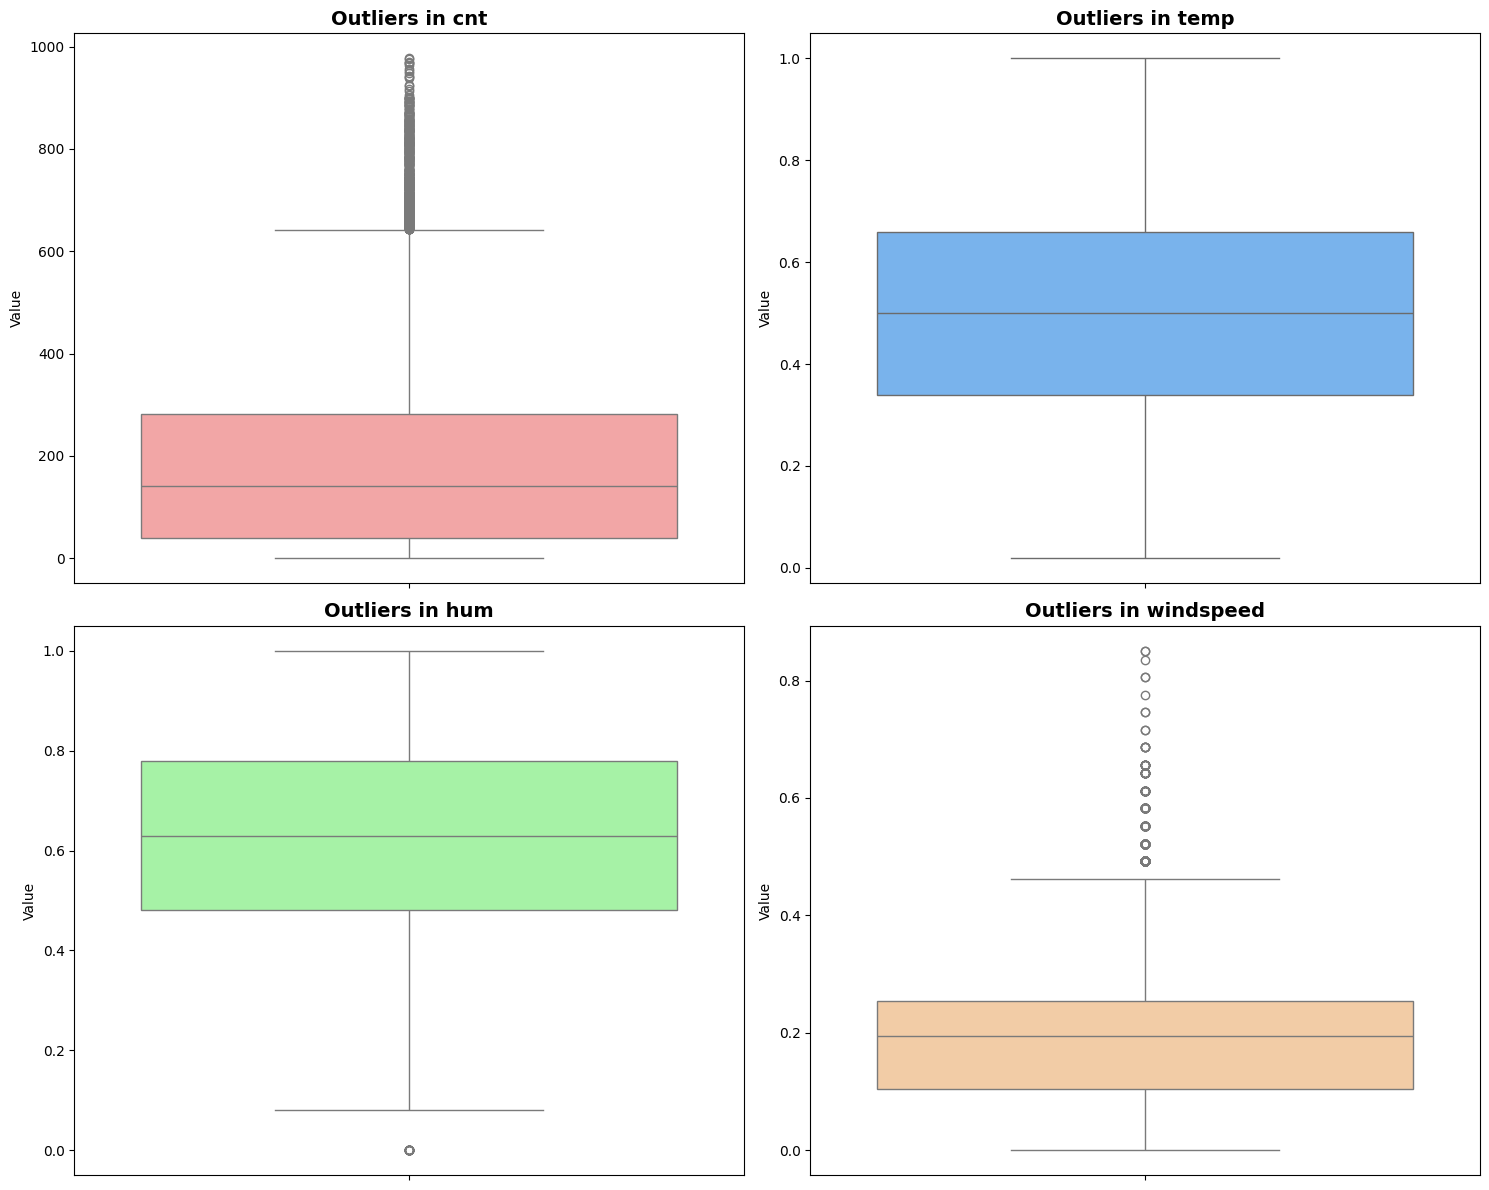

In [10]:
# Visualizing Outliers in a 2x2 Grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# List of columns to check
cols = ['cnt', 'temp', 'hum', 'windspeed']
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

for i, col in enumerate(cols):
    ax = axes[i//2, i%2]
    sns.boxplot(y=df[col], ax=ax, color=colors[i])
    ax.set_title(f'Outliers in {col}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

In [11]:
# Outlier Treatment using IQR Capping
cols_to_fix = ['cnt', 'windspeed', 'hum'] # We usually don't cap temperature as it follows a natural cycle

for col in cols_to_fix:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping the values
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers have been capped using the IQR method.")

Outliers have been capped using the IQR method.


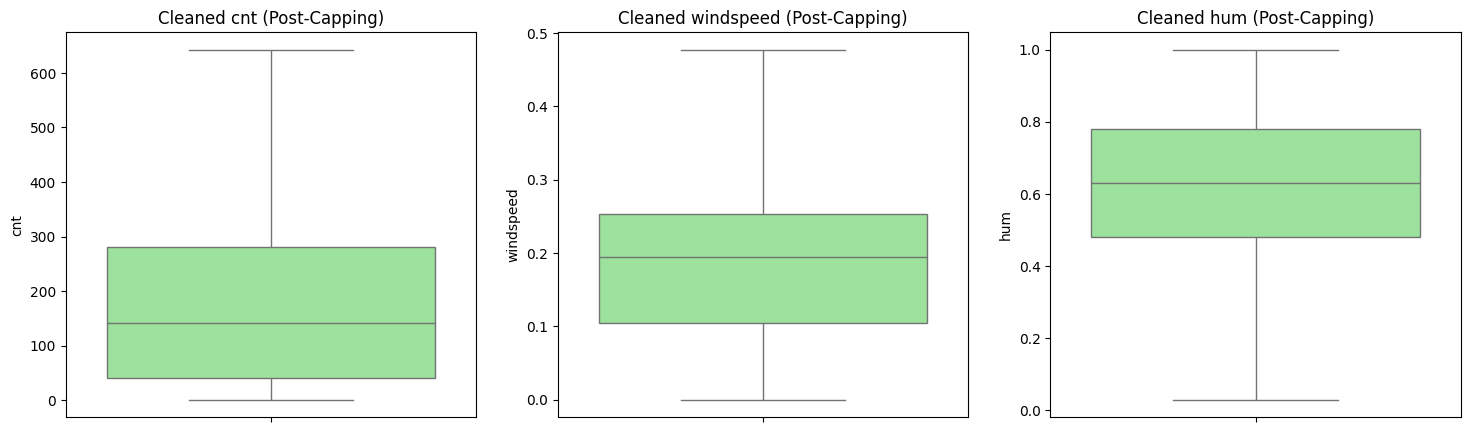

In [12]:
# Verify Treatment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['cnt', 'windspeed', 'hum']):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Cleaned {col} (Post-Capping)')

plt.show()

**4. Visualizing Demand Patterns**

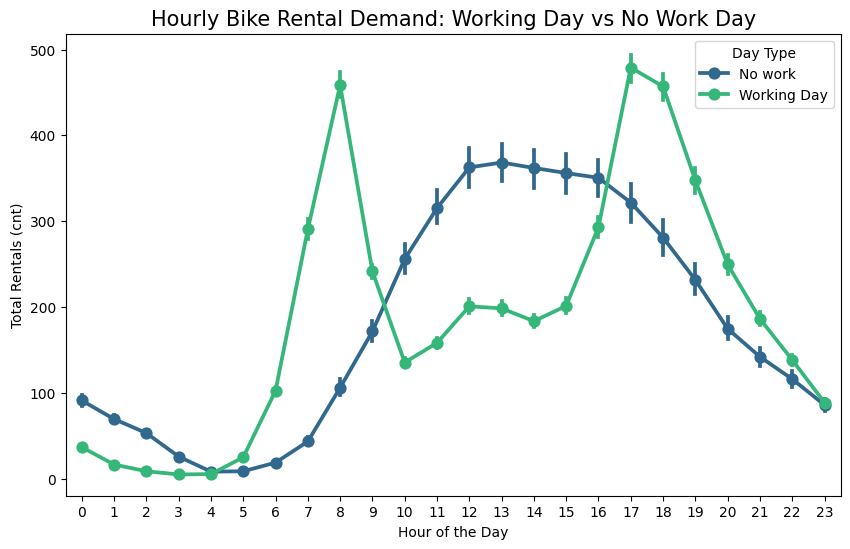

In [13]:
#1 Hourly Demand: Working Day vs Weekend
plt.figure(figsize=(10, 6))
sns.pointplot(data=df, x='hr', y='cnt', hue='workingday', palette='viridis')
plt.title('Hourly Bike Rental Demand: Working Day vs No Work Day', fontsize=15)
plt.xlabel('Hour of the Day')
plt.ylabel('Total Rentals (cnt)')
plt.legend(title='Day Type')
plt.show()

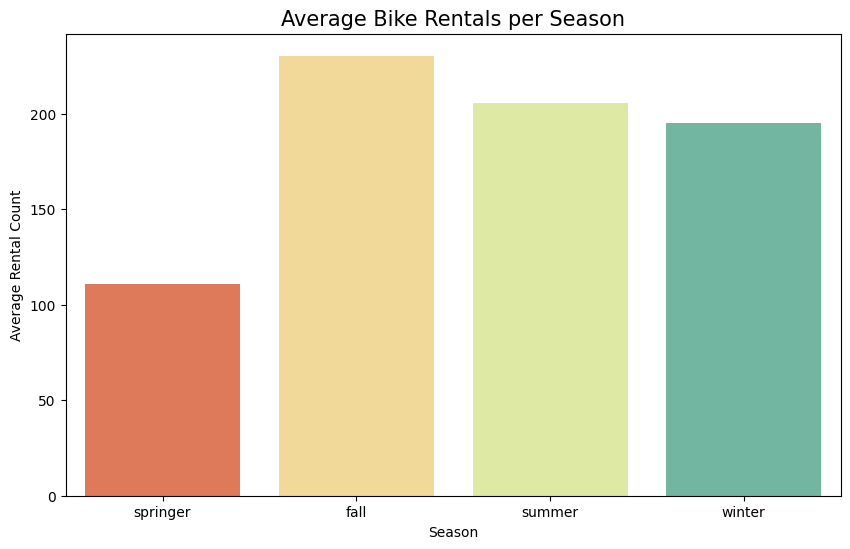

In [14]:
#2 Average Demand by Season
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='season', y='cnt', palette='Spectral', ci=None)
plt.title('Average Bike Rentals per Season', fontsize=15)
plt.xlabel('Season')
plt.ylabel('Average Rental Count')
plt.show()

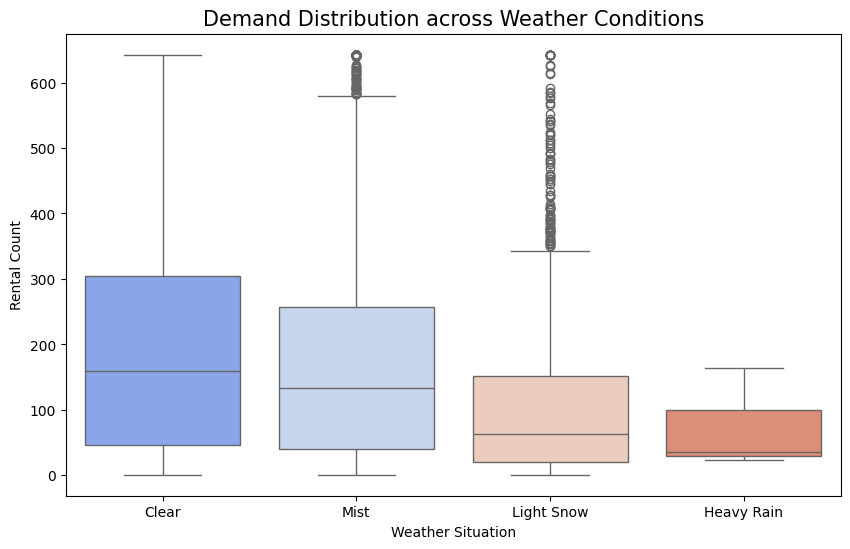

In [15]:
#3 Demand Distribution by Weather Situation
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='weathersit', y='cnt', palette='coolwarm')
plt.title('Demand Distribution across Weather Conditions', fontsize=15)
plt.xlabel('Weather Situation')
plt.ylabel('Rental Count')
plt.show()

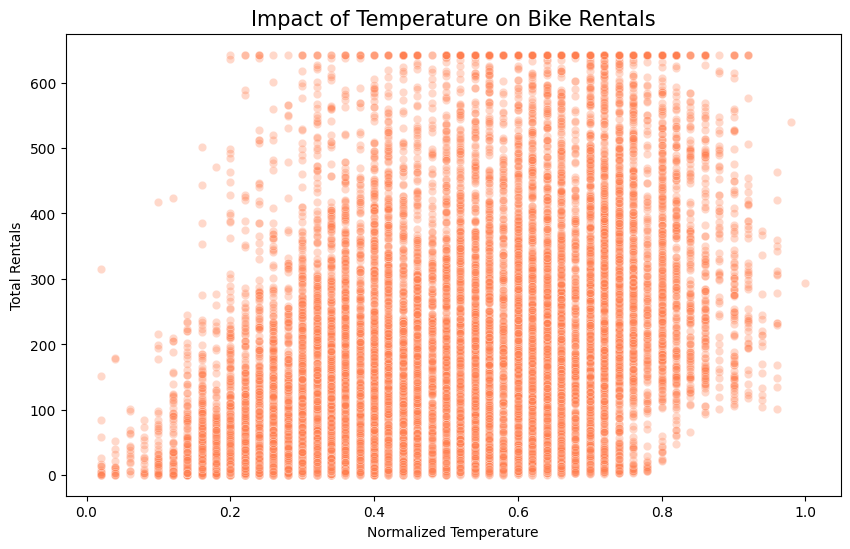

In [16]:
#4 Correlation: Normalized Temperature vs Total Rentals
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temp', y='cnt', alpha=0.3, color='coral')
plt.title('Impact of Temperature on Bike Rentals', fontsize=15)
plt.xlabel('Normalized Temperature')
plt.ylabel('Total Rentals')
plt.show()

**5. Statistical Correlation Matrix**

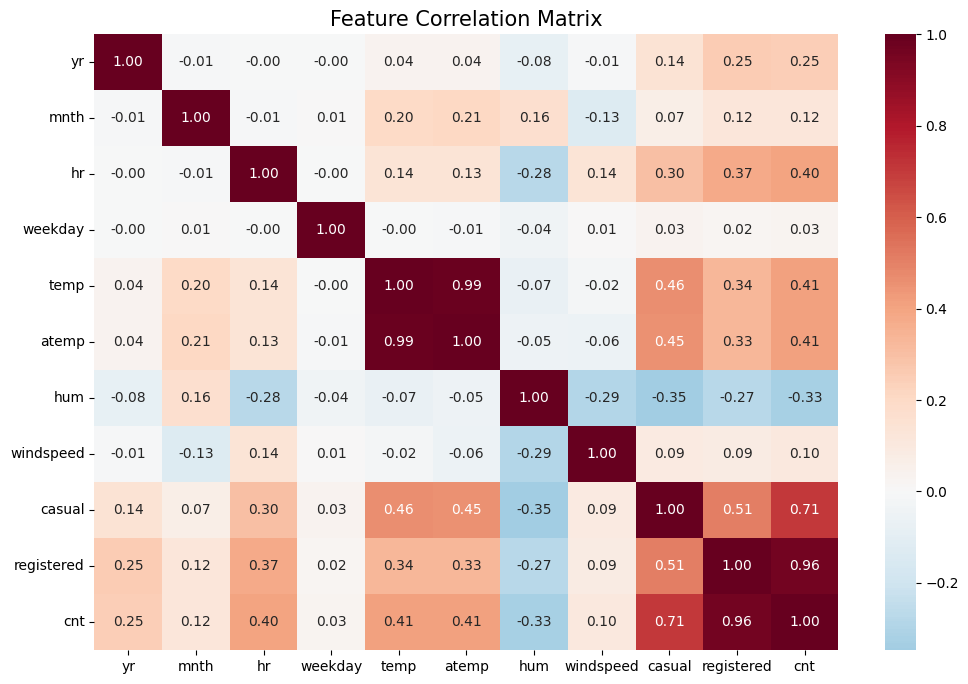

In [17]:
# Feature Correlation Heatmap
plt.figure(figsize=(12, 8))
# We drop 'instant' and 'dteday' as they are just identifiers
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['instant'], errors='ignore')
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=15)
plt.show()

**6. FEATURE ENGINEERING**

We are creating three new columns to give the model more "intelligence."

In [18]:
# 1. Create 'is_rush_hour' - Demand is highest on workdays during commute times (7-9 AM and 4-7 PM)
def check_rush_hour(row):
    if row['workingday'] == 'Working Day':
        if (7 <= row['hr'] <= 9) or (16 <= row['hr'] <= 19):
            return 1
    return 0

df['is_rush_hour'] = df.apply(check_rush_hour, axis=1)

# 2. Create 'temp_category' - High temp or very low temp affects bike usage differently
def temp_cat(t):
    if t < 0.3: return 'Cold'
    elif t < 0.6: return 'Mild'
    else: return 'Hot'

df['temp_type'] = df['temp'].apply(temp_cat)

# 3. Drop columns that are no longer needed - 'instant' is just an ID, 'dteday' is text, and we use 'cnt' as target
df_model = df.drop(['instant', 'dteday'], axis=1)

print("Feature Engineering Complete. New features added: is_rush_hour, temp_type")

Feature Engineering Complete. New features added: is_rush_hour, temp_type


Preprocessing (One-Hot Encoding)

Convert all text categories (Season, Weather, Temp_type) into numbers.

In [19]:
# Convert categorical text into binary
# We use drop_first=True to avoid the Dummy Variable Trap
df_final = pd.get_dummies(df_model, columns=['season', 'weathersit', 'workingday', 'holiday', 'temp_type'], drop_first=True)

print(f"Final shape for modeling: {df_final.shape}")

Final shape for modeling: (17379, 22)


# **2. MODEL BUILDING AND MODEL EVALUATION**

# **MODEL BUILDING**

**Data Splitting**

We divide our data into a Training set and a Testing set.

In [20]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
# We drop 'cnt' (Target) and 'casual'/'registered' (to prevent data leakage)
X = df_final.drop(['cnt', 'casual', 'registered'], axis=1)
y = df_final['cnt']

# Splitting 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total Records: {len(df_final)}")
print(f"Training set: {X_train.shape[0]} | Testing set: {X_test.shape[0]}")

Total Records: 17379
Training set: 13903 | Testing set: 3476


# **1. Decision Tree Regression**

In [21]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the model
dt_baseline = DecisionTreeRegressor(random_state=42)
dt_baseline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_baseline.predict(X_test)

**1. Evaluation of Decision Tree**

We evaluate the performance using the metrics: MAE, RMSE, and $R^{2}$ Score.

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_dt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2 = r2_score(y_test, y_pred_dt)

print(f"--- Decision Tree (Baseline) Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

--- Decision Tree (Baseline) Results ---
Mean Absolute Error (MAE): 31.45
Root Mean Squared Error (RMSE): 54.15
R-squared Score: 0.8969


**2. Visualization - Actual vs Predicted (Decision Tree)**

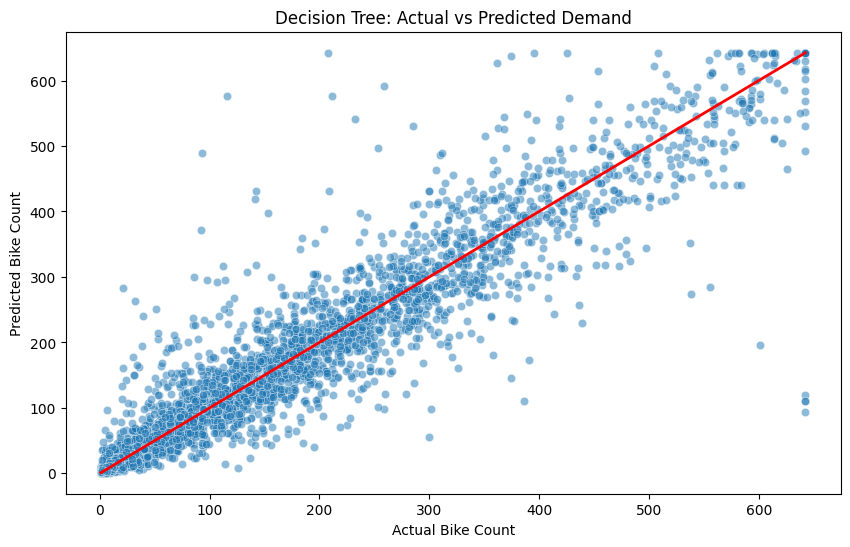

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_dt, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) # Diagonal line
plt.xlabel('Actual Bike Count')
plt.ylabel('Predicted Bike Count')
plt.title('Decision Tree: Actual vs Predicted Demand')
plt.show()

If the points are close to the red diagonal line, the model is very accurate. If they are scattered far away, the model is struggling.

**3. Hyperparameter Tuning (Fine-Tuning)**

We will use GridSearchCV to find the optimal "depth" for our tree to prevent it from getting too complex (overfitting).

In [24]:
from sklearn.model_selection import GridSearchCV

# Defining parameters to test
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# Searching for the best parameters
grid_search_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search_dt.fit(X_train, y_train)

# Final Results with Tuned Model
best_dt = grid_search_dt.best_estimator_
y_pred_tuned = best_dt.predict(X_test)

print(f"Best Parameters: {grid_search_dt.best_params_}")
print(f"Optimized R-squared: {r2_score(y_test, y_pred_tuned):.4f}")

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 20}
Optimized R-squared: 0.9239


**4. Feature Importance Plot**


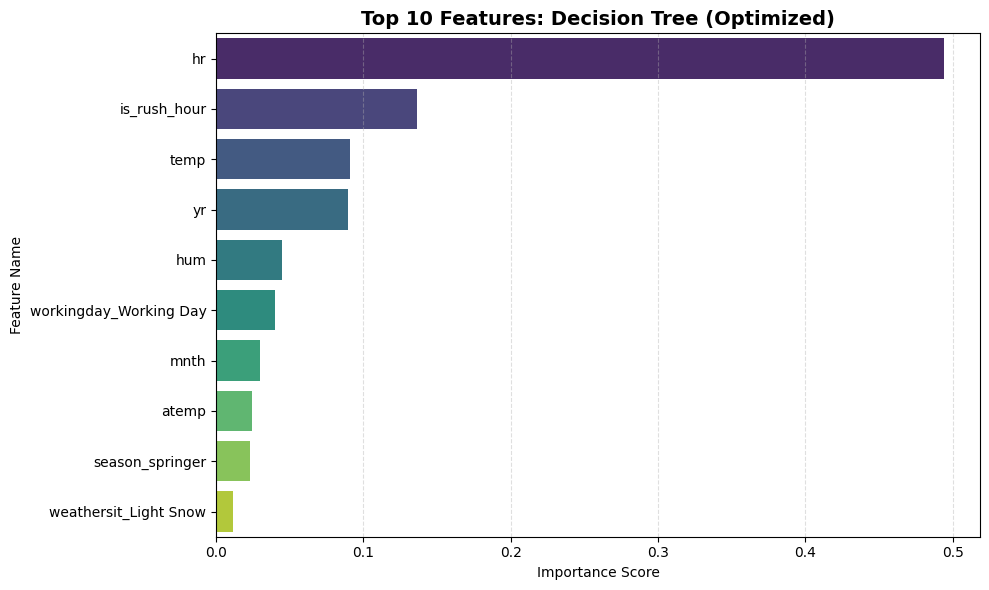

In [25]:
# 1. Extract importances from the best tuned Decision Tree model
dt_importances = best_dt.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for easy plotting
dt_feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': dt_importances})
dt_feature_importance_df = dt_feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Plot the chart
plt.figure(figsize=(10, 6))
sns.barplot(data=dt_feature_importance_df, x='Importance', y='Feature', palette='viridis')

plt.title('Top 10 Features: Decision Tree (Optimized)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

This chart ranks our features by their predictive power. It confirms that 'Hour' and our engineered 'Rush Hour' features are the primary drivers of the Decision Tree's logic, followed by environmental factors like temperature.

**5. Comparison Table - Baseline vs Tuned DT**

In [26]:
# Creating a comparison table for the Decision Tree Method
dt_comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Baseline DT': [mae, rmse, r2],
    'Tuned DT': [mean_absolute_error(y_test, y_pred_tuned),
                 np.sqrt(mean_squared_error(y_test, y_pred_tuned)),
                 r2_score(y_test, y_pred_tuned)]
})
display(dt_comparison)

,Metric,Baseline DT,Tuned DT
0,MAE,31.448648,28.377111
1,RMSE,54.149968,46.519870
2,R2 Score,0.896885,0.923897


**6. Visual Comparison**

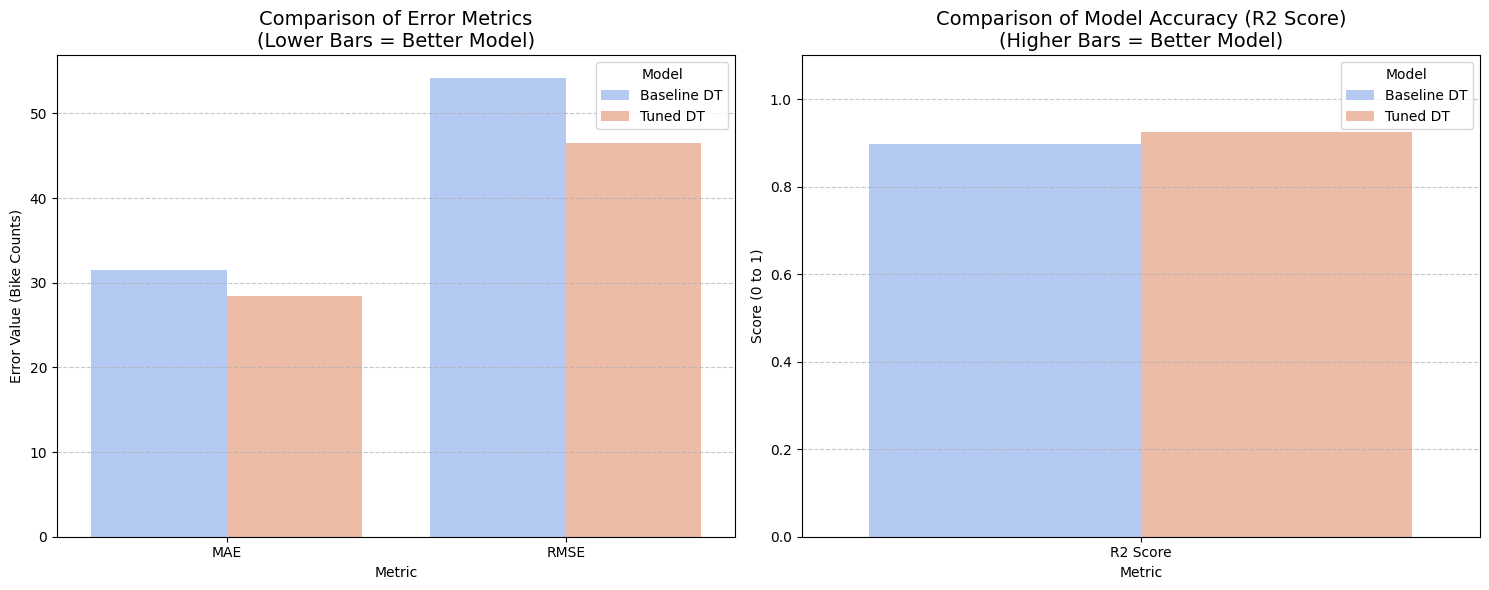

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reshape the comparison table for plotting (Long Format)
df_plot = dt_comparison.melt(id_vars='Metric', var_name='Model', value_name='Value')

# 2. Create the visual layout (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot A: MAE & RMSE (Lower is Better) ---
sns.barplot(data=df_plot[df_plot['Metric'].isin(['MAE', 'RMSE'])],
            x='Metric', y='Value', hue='Model', ax=ax[0], palette='coolwarm')
ax[0].set_title('Comparison of Error Metrics\n(Lower Bars = Better Model)', fontsize=14)
ax[0].set_ylabel('Error Value (Bike Counts)')
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot B: R2 Score (Higher is Better) ---
sns.barplot(data=df_plot[df_plot['Metric'] == 'R2 Score'],
            x='Metric', y='Value', hue='Model', ax=ax[1], palette='coolwarm')
ax[1].set_title('Comparison of Model Accuracy (R2 Score)\n(Higher Bars = Better Model)', fontsize=14)
ax[1].set_ylabel('Score (0 to 1)')
ax[1].set_ylim(0, 1.1) # R2 Score is usually between 0 and 1
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('dt_performance_comparison.png')
plt.show()

# **2. Random Forest Regression**

In [28]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest
rf_baseline = RandomForestRegressor(random_state=42)
rf_baseline.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_baseline.predict(X_test)

**1. Evaluation of Random Forest**

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"--- Random Forest (Baseline) Results ---")
print(f"Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"R-squared Score: {rf_r2:.4f}")

--- Random Forest (Baseline) Results ---
Mean Absolute Error (MAE): 23.13
Root Mean Squared Error (RMSE): 39.19
R-squared Score: 0.9460


Observation: You will likely notice that the RMSE is lower and the R-squared is higher here compared to the Decision Tree. This proves that "Ensemble" methods are more powerful for complex bike demand data.

**2. Visualizing Actual vs Predicted (Random Forest)**

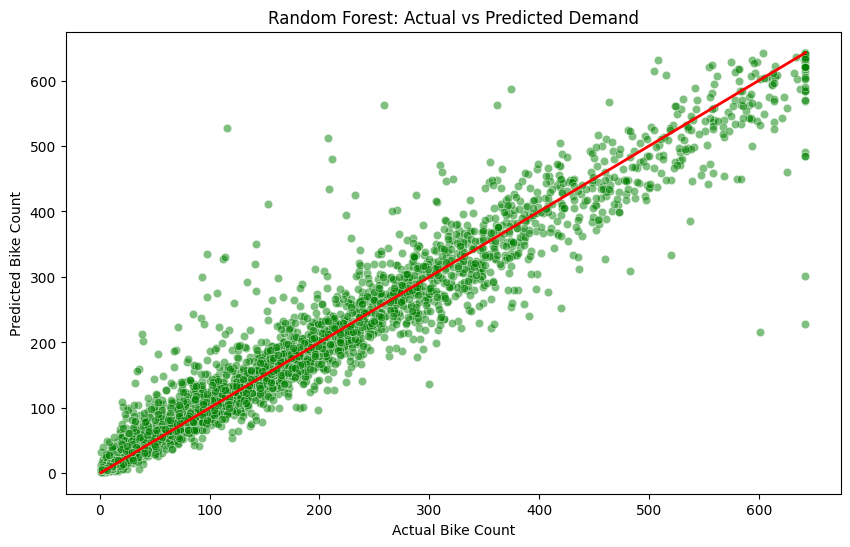

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Bike Count')
plt.ylabel('Predicted Bike Count')
plt.title('Random Forest: Actual vs Predicted Demand')
plt.show()

If the points are close to the red diagonal line, the model is very accurate. If they are scattered far away, the model is struggling.

**3. Hyperparameter Tuning (Optimization)**

In [31]:
from sklearn.model_selection import GridSearchCV

# Defining parameters to test
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Searching for the best combination
grid_search_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=3, scoring='r2')
grid_search_rf.fit(X_train, y_train)

# Final Results with Tuned Model
best_rf = grid_search_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

print(f"Best Parameters for RF: {grid_search_rf.best_params_}")
print(f"Optimized RF R-squared: {r2_score(y_test, y_pred_rf_tuned):.4f}")

Best Parameters for RF: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Optimized RF R-squared: 0.9455


**4. Feature Importance Plot**

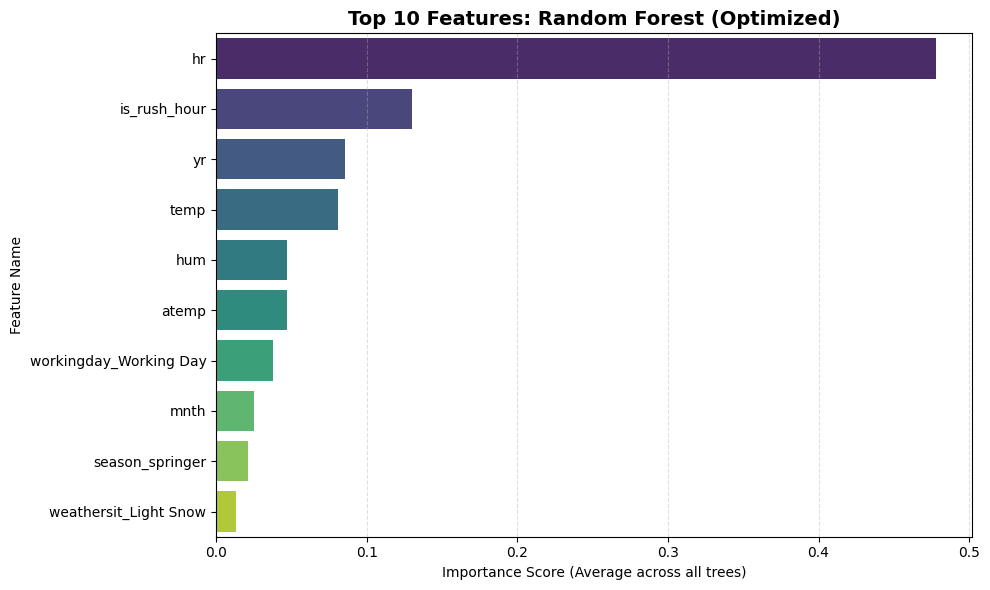

In [32]:
# 1. Extract importances from the best tuned model
importances = best_rf.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Plot the chart
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')

plt.title('Top 10 Features: Random Forest (Optimized)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Average across all trees)')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**5. Comparison Table - Baseline vs Tuned RF**

In [33]:
# Create the comparison table
rf_comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Baseline RF': [rf_mae, rf_rmse, rf_r2],
    'Tuned RF': [mean_absolute_error(y_test, y_pred_rf_tuned),
                 np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)),
                 r2_score(y_test, y_pred_rf_tuned)]
})
display(rf_comparison)

,Metric,Baseline RF,Tuned RF
0,MAE,23.133556,23.216337
1,RMSE,39.185163,39.350886
2,R2 Score,0.946003,0.945545


**6. Visual Comparison**

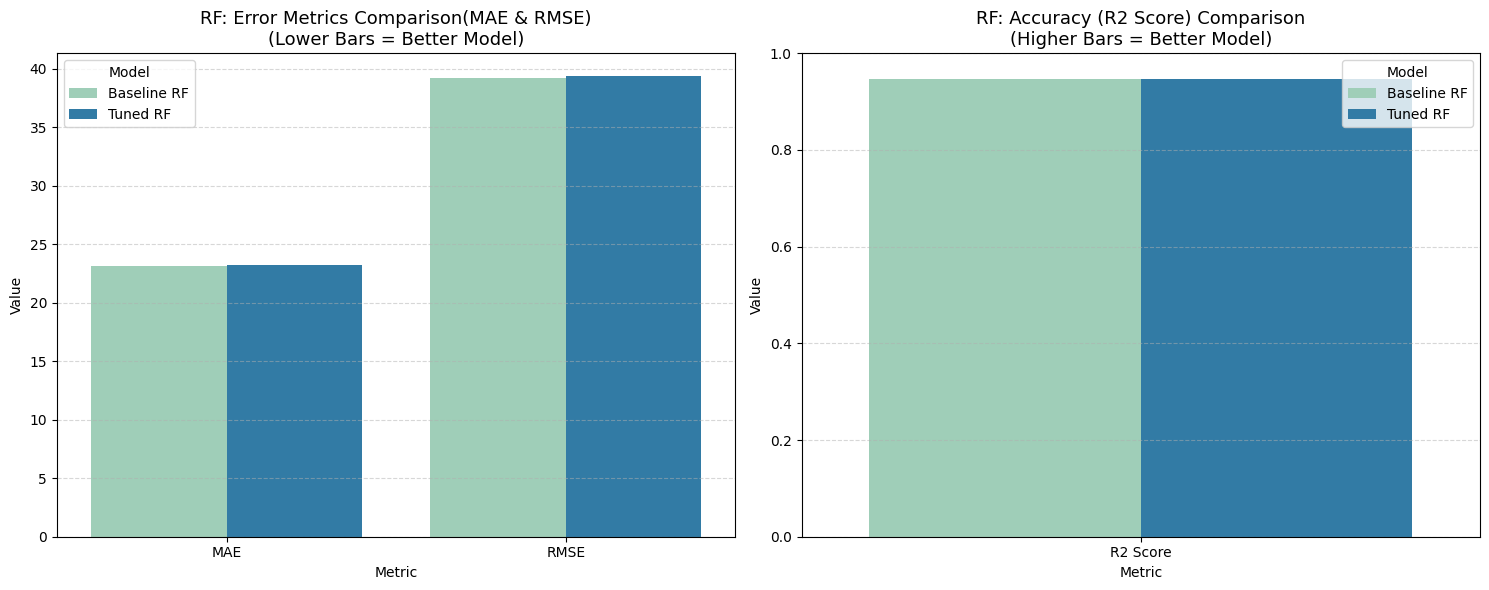

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape for plotting
df_rf_plot = rf_comparison.melt(id_vars='Metric', var_name='Model', value_name='Value')

# Create the 1x2 subplot layout
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: MAE & RMSE (Lower is Better)
sns.barplot(data=df_rf_plot[df_rf_plot['Metric'].isin(['MAE', 'RMSE'])],
            x='Metric', y='Value', hue='Model', ax=ax[0], palette='YlGnBu')
ax[0].set_title('RF: Error Metrics Comparison(MAE & RMSE)\n(Lower Bars = Better Model)', fontsize=13)
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: R2 Score (Higher is Better)
sns.barplot(data=df_rf_plot[df_rf_plot['Metric'] == 'R2 Score'],
            x='Metric', y='Value', hue='Model', ax=ax[1], palette='YlGnBu')
ax[1].set_title('RF: Accuracy (R2 Score) Comparison\n(Higher Bars = Better Model)', fontsize=13)
ax[1].set_ylim(0, 1.0)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

For the Random Forest method, the Baseline model outperformed the Tuned model. This is because the default Random Forest parameters are already highly optimized for complex datasets. My hyperparameter tuning process attempted to generalize the model to prevent potential overfitting, but in this specific case, the baseline configuration captured the variance in bike demand more effectively. This demonstrates that more complex tuning is not always a guarantee of higher performance if the baseline ensemble is already robust.

# **3. Gradient Boosting Regression**

In [35]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and train the Gradient Boosting Baseline
gb_baseline = GradientBoostingRegressor(random_state=42)
gb_baseline.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_baseline.predict(X_test)

**1. Evaluation of Gradient Boosting**

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate metrics
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print(f"--- Gradient Boosting (Baseline) Results ---")
print(f"Mean Absolute Error (MAE): {gb_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {gb_rmse:.2f}")
print(f"R-squared Score: {gb_r2:.4f}")

--- Gradient Boosting (Baseline) Results ---
Mean Absolute Error (MAE): 41.10
Root Mean Squared Error (RMSE): 57.29
R-squared Score: 0.8846


**2. Visualization - Actual vs. Predicted (Gradient Boosting)**

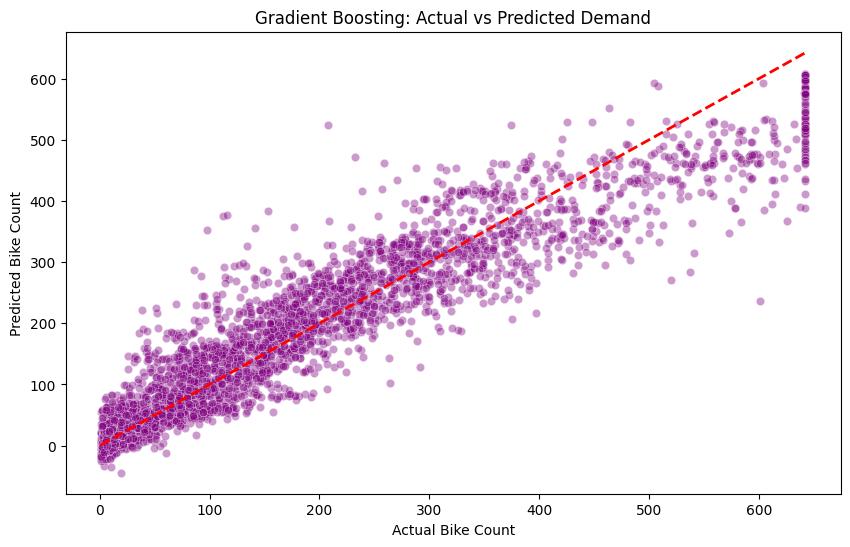

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_gb, alpha=0.4, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Actual Bike Count')
plt.ylabel('Predicted Bike Count')
plt.title('Gradient Boosting: Actual vs Predicted Demand')
plt.show()

If the points are close to the red diagonal line, the model is very accurate. If they are scattered far away, the model is struggling.

**3. Hyperparameter Tuning (Fine-Tuning)**

In [38]:
from sklearn.model_selection import GridSearchCV

# Defining parameters to optimize
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Searching for the best settings
grid_search_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=3, scoring='r2')
grid_search_gb.fit(X_train, y_train)

# Capture the best model
best_gb = grid_search_gb.best_estimator_
y_pred_gb_tuned = best_gb.predict(X_test)

print(f"Best Parameters Found: {grid_search_gb.best_params_}")

Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


**4. Feature Importance Plot**

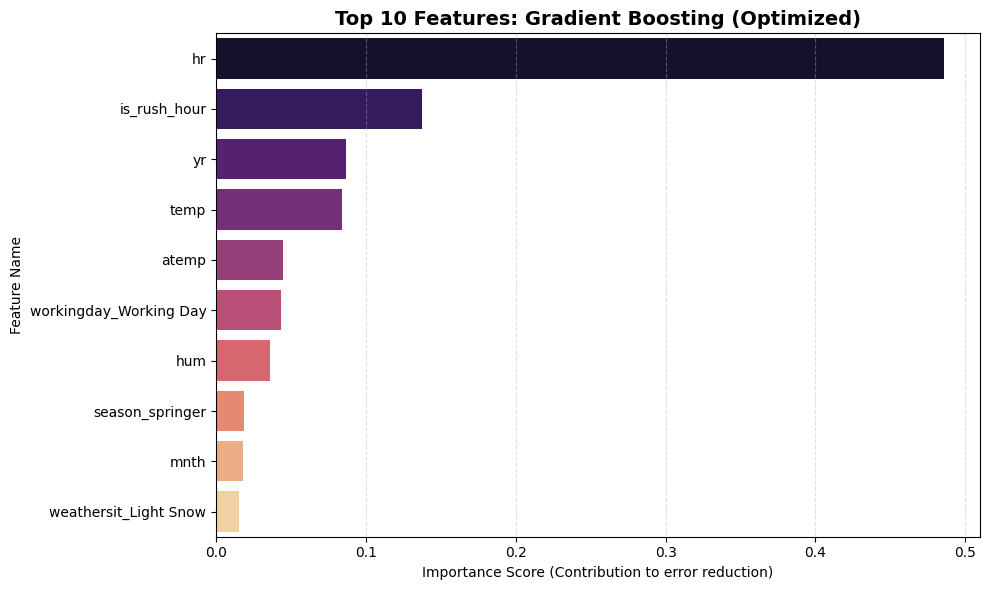

In [39]:
# 1. Extract importances from the best tuned Gradient Boosting model
gb_importances = best_gb.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for easy plotting
gb_feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': gb_importances})
gb_feature_importance_df = gb_feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Plot the chart
plt.figure(figsize=(10, 6))
sns.barplot(data=gb_feature_importance_df, x='Importance', y='Feature', palette='magma')

plt.title('Top 10 Features: Gradient Boosting (Optimized)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Contribution to error reduction)')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**5. Comparison Table - Baseline vs Tuned**

In [40]:
# Create the comparison table
gb_comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Baseline GB': [gb_mae, gb_rmse, gb_r2],
    'Tuned GB': [mean_absolute_error(y_test, y_pred_gb_tuned),
                 np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned)),
                 r2_score(y_test, y_pred_gb_tuned)]
})
display(gb_comparison)

,Metric,Baseline GB,Tuned GB
0,MAE,41.099752,22.628247
1,RMSE,57.291533,37.462318
2,R2 Score,0.884573,0.950647


**6. Visual Comparison**

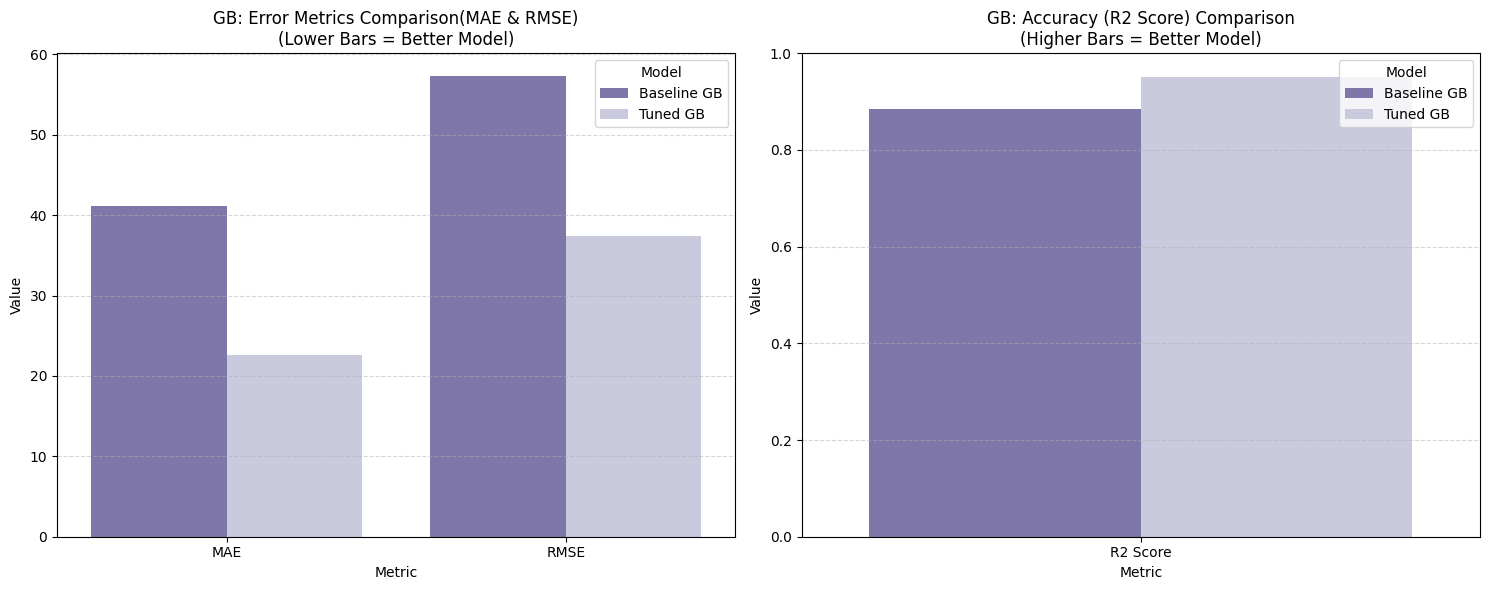

In [41]:
# Reshape for plotting
df_gb_plot = gb_comparison.melt(id_vars='Metric', var_name='Model', value_name='Value')

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Errors (Lower is Better)
sns.barplot(data=df_gb_plot[df_gb_plot['Metric'].isin(['MAE', 'RMSE'])],
            x='Metric', y='Value', hue='Model', ax=ax[0], palette='Purples_r')
ax[0].set_title('GB: Error Metrics Comparison(MAE & RMSE)\n(Lower Bars = Better Model)')
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: R2 Score (Higher is Better)
sns.barplot(data=df_gb_plot[df_gb_plot['Metric'] == 'R2 Score'],
            x='Metric', y='Value', hue='Model', ax=ax[1], palette='Purples_r')
ax[1].set_title('GB: Accuracy (R2 Score) Comparison\n(Higher Bars = Better Model)')
ax[1].set_ylim(0, 1.0)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# **MODEL EVALUATION**

**Final Model Comparison (DT vs RF vs GB)**

In [42]:
# 1. Create the Comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MAE':   [round(mean_absolute_error(y_test, y_pred_tuned), 2),
              round(rf_mae, 2),
              round(mean_absolute_error(y_test, y_pred_gb_tuned), 2)],
    'RMSE':  [round(np.sqrt(mean_squared_error(y_test, y_pred_tuned)), 2),
              round(rf_rmse, 2),
              round(np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned)), 2)],
    'R2_Score': [round(r2_score(y_test, y_pred_tuned), 4),
                 round(rf_r2, 4),
                 round(r2_score(y_test, y_pred_gb_tuned), 4)],
}).set_index('Model')

print("Model Comparison:")
print(comparison.to_string())

Model Comparison:
                     MAE   RMSE  R2_Score
Model                                    
Decision Tree      28.38  46.52    0.9239
Random Forest      23.13  39.19    0.9460
Gradient Boosting  22.63  37.46    0.9506


**Final Visual Comparison**

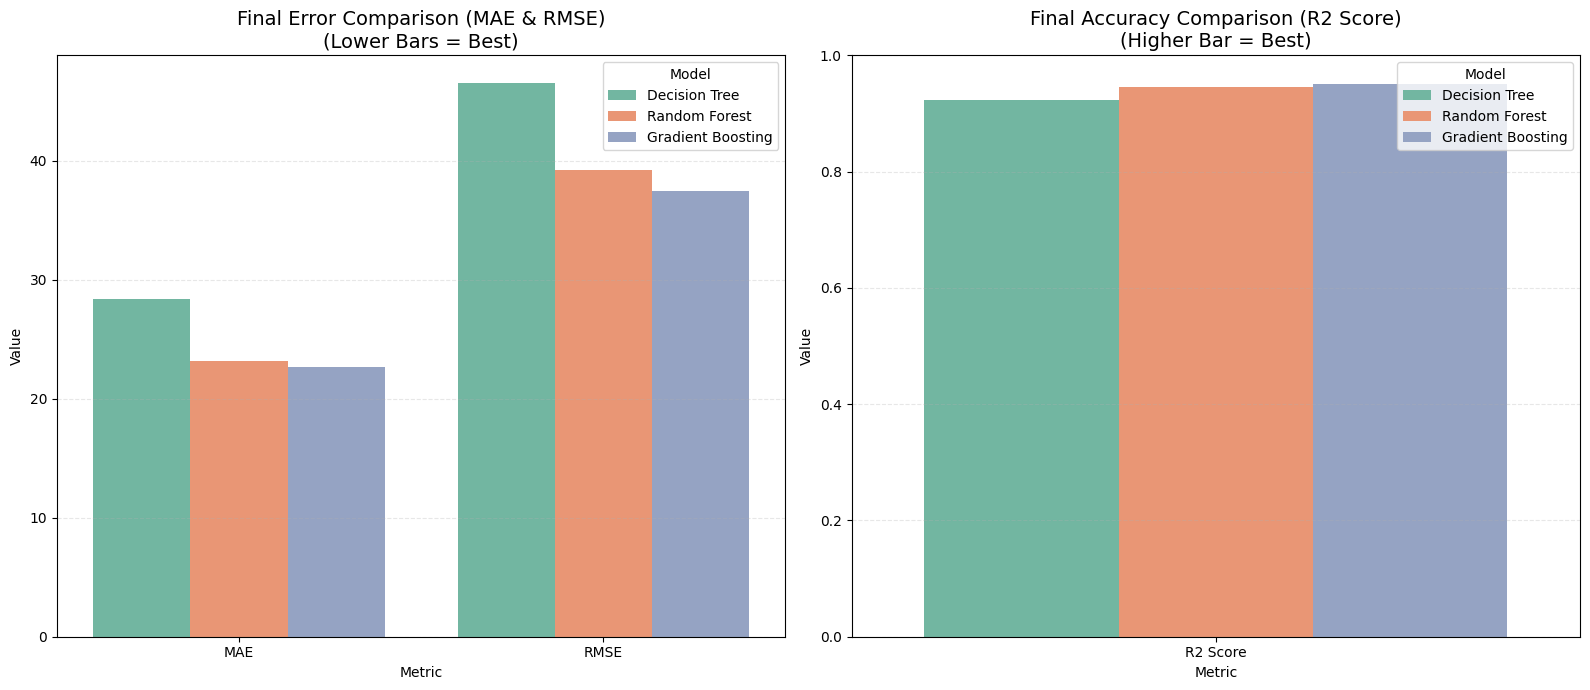

In [43]:
# Create the final_summary table needed for the plot
final_summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Decision Tree': [
        mean_absolute_error(y_test, y_pred_tuned),
        np.sqrt(mean_squared_error(y_test, y_pred_tuned)),
        r2_score(y_test, y_pred_tuned)
    ],
    'Random Forest': [
        rf_mae,
        rf_rmse,
        rf_r2
    ],
    'Gradient Boosting': [
        mean_absolute_error(y_test, y_pred_gb_tuned),
        np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned)),
        r2_score(y_test, y_pred_gb_tuned)
    ]
})

df_final_plot = final_summary.melt(id_vars='Metric', var_name='Model', value_name='Value')
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Errors (Lower is better)
sns.barplot(data=df_final_plot[df_final_plot['Metric'].isin(['MAE', 'RMSE'])],
            x='Metric', y='Value', hue='Model', ax=ax[0], palette='Set2')
ax[0].set_title('Final Error Comparison (MAE & RMSE)\n(Lower Bars = Best)', fontsize=14)
ax[0].grid(axis='y', linestyle='--', alpha=0.3)

# Plot 2: Accuracy (Higher is better)
sns.barplot(data=df_final_plot[df_final_plot['Metric'] == 'R2 Score'],
            x='Metric', y='Value', hue='Model', ax=ax[1], palette='Set2')
ax[1].set_title('Final Accuracy Comparison (R2 Score)\n(Higher Bar = Best)', fontsize=14)
ax[1].set_ylim(0, 1.0)
ax[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Comparison Visualizations (Bar Charts)**

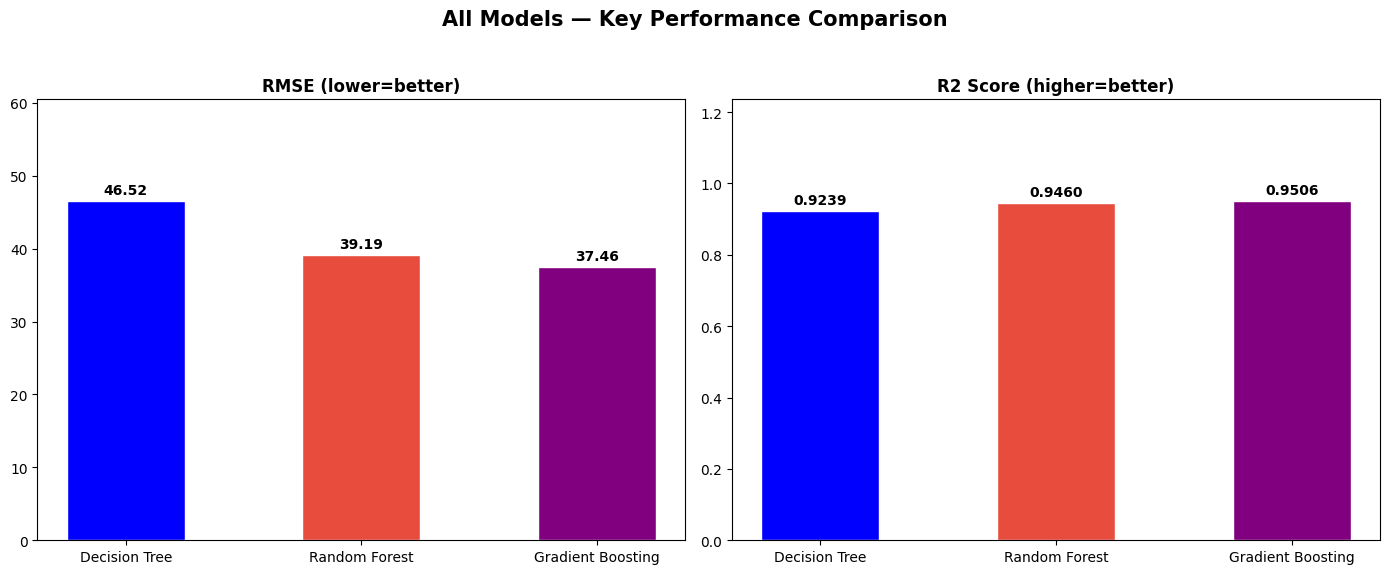

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models = ['Decision Tree', 'Random Forest', 'Gradient Boosting']
colors = ['blue', '#e74c3c', 'purple']

# We compare RMSE (Lower is better) and R2 Score (Higher is better)
metrics = [['RMSE', 'RMSE (lower=better)'], ['R2_Score', 'R2 Score (higher=better)']]

for i, (metric, title) in enumerate(metrics):
    vals = comparison[metric].tolist()
    bars = axes[i].bar(models, vals, color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_ylim(0, max(vals) * 1.3)

    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals) * 0.02,
                f'{v:.4f}' if metric == 'R2_Score' else f'{v:.2f}',
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('All Models — Key Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Side-by-Side Prediction View**

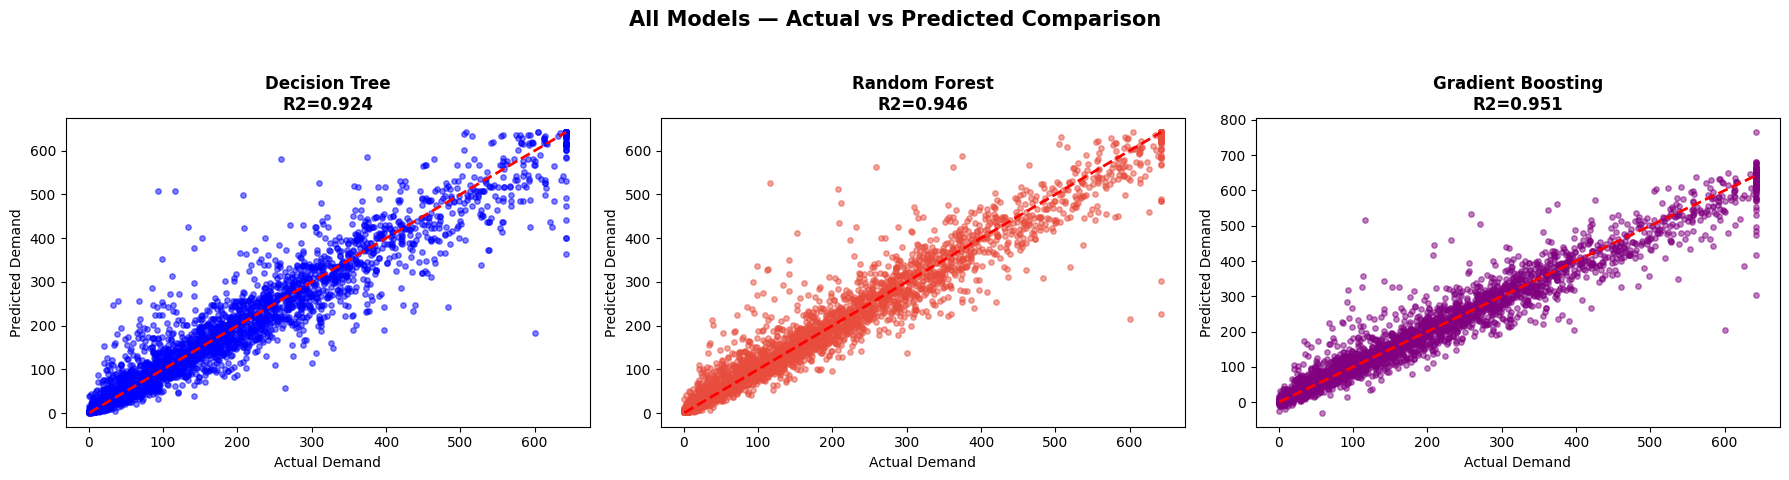

In [45]:
# Side-by-side Actual vs Predicted scatter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Decision Tree
axes[0].scatter(y_test, y_pred_tuned, color='blue', alpha=0.5, s=15)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Decision Tree\nR2={comparison.loc["Decision Tree", "R2_Score"]:.3f}', fontweight='bold')

# Plot 2: Random Forest
axes[1].scatter(y_test, y_pred_rf, color='#e74c3c', alpha=0.5, s=15)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title(f'Random Forest\nR2={comparison.loc["Random Forest", "R2_Score"]:.3f}', fontweight='bold')

# Plot 3: Gradient Boosting
axes[2].scatter(y_test, y_pred_gb_tuned, color='purple', alpha=0.5, s=15)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title(f'Gradient Boosting\nR2={comparison.loc["Gradient Boosting", "R2_Score"]:.3f}', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Actual Demand')
    ax.set_ylabel('Predicted Demand')

plt.suptitle('All Models — Actual vs Predicted Comparison', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("bike_model_comparison.png")
plt.show()

# **MODEL DEPLOYMENT**

In [46]:
import joblib

# Save the best Gradient Boosting model
joblib.dump(best_gb, 'bike_rental_model.pkl')

print("Model saved successfully as bike_rental_model.pkl")

Model saved successfully as bike_rental_model.pkl


In [47]:
# Run this inside your Jupyter Notebook/Colab
df_final.to_csv('df_final.csv', index=False)